# Do pension funds knock stocks down at month-end? 🔄
### The month-end rebalancing story, tested in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![TOM is flows in disguise?: Busted](https://img.shields.io/badge/TOM_is_flows_in_disguise%3F-Busted-8b949e?style=flat-square)

Every few weeks a note does the rounds on trading desks: *"stocks beat bonds by 6% this month, so pension funds and target-date funds must sell $XX billion of equities to rebalance — expect selling into month-end and a bounce in the first days of the new month."* It sounds mechanical, almost too easy: the funds' own rulebooks force them to sell whatever just won.

So we tested it — 33 years of the S&P 500 (SPY) against the broad bond market, one month at a time. The short version: **half the story is real, half is a costume.**

> 📓 **Plain-language layer.** Want the *t*-stats, the permutation placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Data note.** Equity = SPY; bonds = the Vanguard Total Bond Market fund until 2003, the AGG ETF after (same index, splice documented). All total-return. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from month_end_rebalancing_flows import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    RETS = data.load_real()
    TAB = st.month_table(RETS)
else:
    RETS = TAB = None
print("real cache present:", HAVE_REAL,
      "| months:", (0 if TAB is None else len(TAB)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-02-01', 'end': '2026-06-30', 'n_months': 401, 'n_days': 8410, 'splice': '2003-09-30', 'fingerprint': '3efe1915419d', 'as_of': '2026-06-30', 'sell': {'top_bps': -46.53, 't_top': -2.88, 'bot_bps': 11.58, 't_bot': 0.36, 'uncond_bps': -19.13, 't_uncond': -2.07, 'diff_bps': -58.11, 'welch': -1.6, 'top_vs_uncond': -1.47, 'p_mean': 0.0225, 'p_lo': 0.0175, 'p_hi': 0.03, 'n_top': 81, 'n': 401}, 'rev': {'top_bps': 50.67, 't_top': 2.26, 'bot_bps': 13.96, 't_bot': 0.44, 'uncond_bps': 33.54, 't_uncond': 3.28, 'diff_bps': 36.7, 'welch': 0.95, 'p_mean': 0.1317, 'p_lo': 0.124, 'p_hi': 0.1435, 'n_top': 80, 'n': 400}, 'dose': [(1, -5.32, 11.58, 0.36, 13.96, 0.44), (2, -0.92, 2.22, 0.14, 45.78, 2.0), (3, 1.2, -19.75, -1.19, 29.96, 1.54), (4, 2.87, -43.63, -2.75, 27.33, 1.81), (5, 6.22, -46.45, -2.84, 50.67, 2.26)], 'era': [('1993-2003', -69.18, -1.95, -0.99, -0.01, 3.52, 0.08, -29.92, -0.38), ('2004-2015', -50.99, -2.17, -116.71, -2.14, 135.5, 5.22, 180.14, 3.22), ('2016+', -12.07, -0.57, -50.71, -0.95, -8.54, -0.24, -92.89, -1.52)], 'windows': [(2, -42.39, -2.74, -1.9, 61.18, 3.61, 1.96), (3, -46.53, -2.88, -1.6, 50.67, 2.26, 0.95), (4, -55.51, -3.13, -3.61, 66.1, 2.82, 1.72)], 'trade': [('2 bps/leg, full tape', 70, 1.72, 2.52), ('5 bps/leg, full tape', 70, 1.22, 1.78), ('2 bps, 1993-2015', 46, 2.9, 3.42), ('2 bps, 2016-2026', 26, -0.07, -0.07)], 'trade_gross_pct': 2.06, 'per_event_gross_bps': 98.1, 'per_event_cost_bps': 16, 'share_active_pct': 5.0, 'tom': {'uncond_bps': 34.41, 't_uncond': 3.55, 'mid_bps': 36.35, 't_mid': 3.45, 'top_bps': 43.88, 't_top': 2.05, 'bot_bps': 19.12, 't_bot': 0.64, 'welch_ext_mid': -0.23, 'n_mid': 240, 'n_ext': 160}, 'syn': {'null_mean': -0.04, 'null_sd': 0.59, 'null_max_abs': 1.79, 'null_seeds': 20, 'planted_sell_welch': -9.26, 'planted_rev_welch': 5.66, 'planted_net_pct': 4.35, 'planted_hac': 7.04, 'null_net_pct': 0.04, 'null_hac': 0.07}}


real cache present: True | months: 401


## The answer first

| Question | Answer |
|---|---|
| After stocks trounce bonds, do stocks lag into month-end? | **Yes — really.** In the top fifth of stocks-beat-bonds months, equities trail bonds by about **half a percent over the final three days** — and the bigger the month's gap, the bigger the drag. |
| Does the pressure bounce back in the first days? | **The bounce is real, the story isn't.** Stocks *do* pop in the first days of a new month — but they pop **whether or not** there was anything to rebalance. That's the old turn-of-the-month drift, not a rebalancing snap-back. |
| Could you trade it? | **Once upon a time.** A fade-the-winner trade made money for two decades (through 2015) — and has made **nothing since 2016**. |
| Is the famous turn-of-the-month effect secretly this? | **No.** The month-start pop is just as strong in months where stocks and bonds finished neck-and-neck — when rebalancers had nothing to do. |

## 1 · The claim

> *"Institutions run fixed stock/bond mixes (60/40 and friends). When stocks trounce bonds during a month, their weights drift — so at month-end they **must sell stocks and buy bonds** to get back to policy. That forced selling depresses stocks over the last few days, and once the calendar turns, the pressure lifts and prices bounce."*

This is not just folklore: academics have documented month-turn flow pressure (Etula, Rinne, Suominen & Vaittinen's *Dash for Cash*) and target-date funds really do trade against the month's winner by construction (Parker, Schoar & Sun). The question is whether the effect shows up on the tape **when the rule says it should** — that's what separates a *flow* story from a plain calendar habit.

## 2 · So what?

If true, it's the dream setup: a **forced seller** whose calendar you know in advance. You'd step aside (or short) into month-end after big equity months and buy the turn.

But here's the trap this study is built to catch: the market *already has* a famous unconditional month-turn pattern — the turn-of-the-month drift (our [study 89](../../89-turn-of-the-month/)). A lazy test would find "selling into month-end, bounce after" and cry *rebalancing!* when it's really just the calendar. The fingerprint of a genuine **flow** effect is *conditionality*: it should be big when the month's stock-bond gap is big, and absent when there's nothing to rebalance.

## 3 · How would we even know?

For each of **401 complete months** (1993-02-01 → 2026-06-30):

1. **Measure the month's race** — the stock-minus-bond return gap, up to three days before month-end (so the signal exists *before* the window it predicts).
2. **Watch the last 3 trading days** — did stocks lag bonds when the rule says rebalancers were selling?
3. **Watch the first 3 days of the next month** — did the pressure reverse?
4. **Sort months into five buckets** by the gap and compare the extremes — plus a shuffle test: would randomly re-labelled months look just as good?

## 4 · The teardown — let's actually look

**The sell-the-winner leg.** Average stock-minus-bond return over the **last 3 days** of the month, by how much stocks had beaten bonds up to that point.

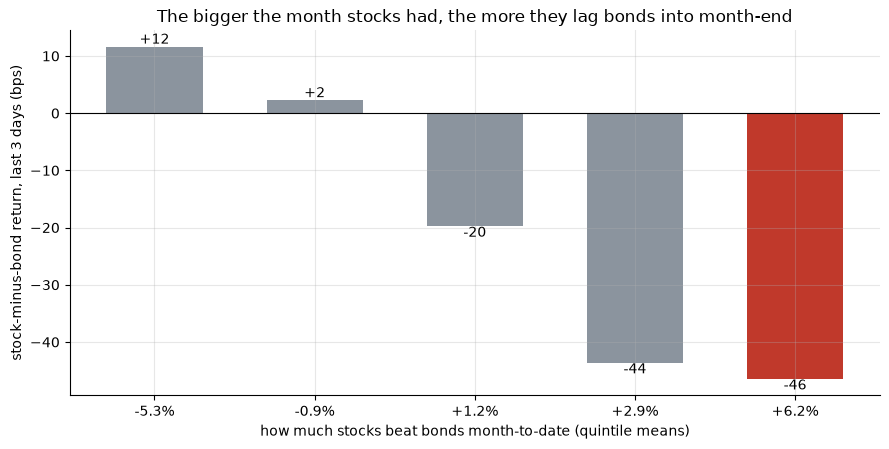

last-3-day spread by gap quintile (bps): [11.6, 2.2, -19.7, -43.6, -46.4]


In [2]:
if HAVE_REAL:
    prof = st.quintile_profile(TAB, 'gap_pre', 'last_spread')
    vals = prof['mean_bps'].tolist(); gaps = prof['cond_mean_pct'].tolist()
else:
    vals = [d[2] for d in R['dose']]; gaps = [d[1] for d in R['dose']]
labels = [f'{g:+.1f}%' for g in gaps]
colors = [GREY]*4 + [RED]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.bar(labels, vals, color=colors, width=.6)
for i, v in enumerate(vals): ax.annotate(f'{v:+.0f}', (i, v), ha='center',
    va='bottom' if v > 0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('how much stocks beat bonds month-to-date (quintile means)')
ax.set_ylabel('stock-minus-bond return, last 3 days (bps)')
ax.set_title('The bigger the month stocks had, the more they lag bonds into month-end')
plt.tight_layout(); plt.show()
print('last-3-day spread by gap quintile (bps):', [round(v,1) for v in vals])

A clean staircase: months where stocks were barely ahead show nothing, and the **biggest winner months end with stocks trailing bonds by -47 bps over three days** — a pattern a random shuffle of the calendar almost never produces (about a **1-in-45** fluke; the quants notebook has the details). The sell-the-winner half of the story is on the tape.

**The "bounce" leg — here's the costume.** Same picture for the **first 3 days of the next month**. If this were rebalancing pressure reversing, the bounce should live in the right-hand bars only.

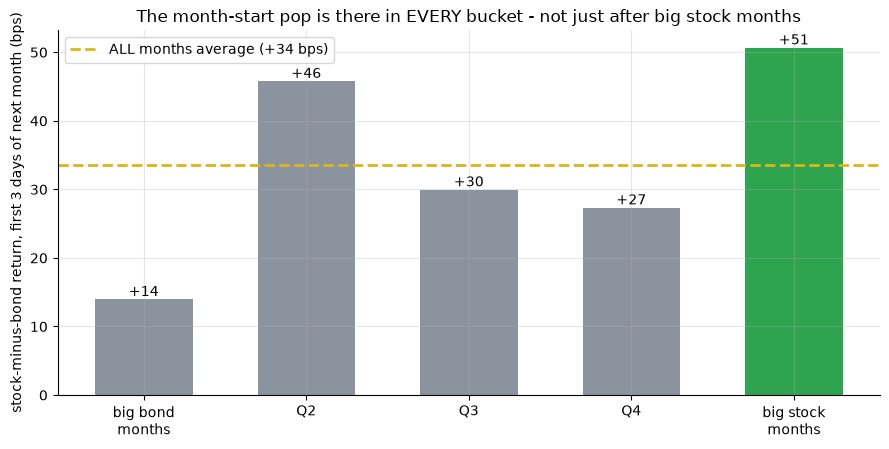

first-3-day spread by prior-gap quintile (bps): [14.0, 45.8, 30.0, 27.3, 50.7]


In [3]:
if HAVE_REAL:
    prof2 = st.quintile_profile(TAB, 'gap_full', 'first_spread')
    vals2 = prof2['mean_bps'].tolist()
    unc = float(TAB['first_spread'].mean()) * 1e4
else:
    vals2 = [d[4] for d in R['dose']]; unc = R['rev']['uncond_bps']
labels2 = ['big bond\nmonths', 'Q2', 'Q3', 'Q4', 'big stock\nmonths']
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.bar(labels2, vals2, color=[GREY, GREY, GREY, GREY, GREEN], width=.6)
ax.axhline(unc, ls='--', c=AMBER, lw=2, label=f'ALL months average ({unc:+.0f} bps)')
for i, v in enumerate(vals2): ax.annotate(f'{v:+.0f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('stock-minus-bond return, first 3 days of next month (bps)')
ax.set_title('The month-start pop is there in EVERY bucket - not just after big stock months')
ax.legend(); plt.tight_layout(); plt.show()
print('first-3-day spread by prior-gap quintile (bps):', [round(v,1) for v in vals2])

Stocks beat bonds by **+34 bps** in the first three days of a month *on average* — after big stock months, after big bond months, after flat months. There's no staircase here: the "rebalancing bounce" is really the plain old **turn-of-the-month drift** wearing a rebalancing costume.

**Could you have traded the real half?** Fade the winner: when the month-to-date gap is in the top fifth of everything seen so far, short stocks / long bonds for the last 3 days, then flip for the first 3. Realistic costs, and the threshold only uses past months (no crystal ball).

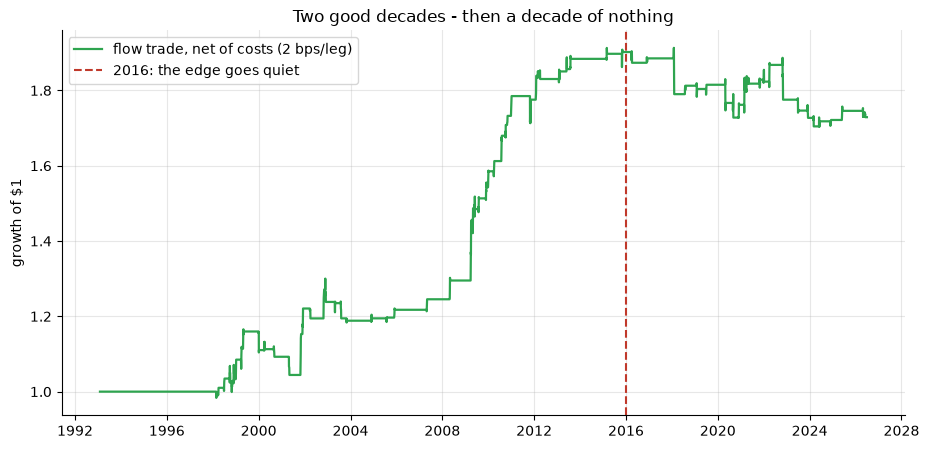

net +1.72%/yr over the full tape (70 events)


In [4]:
if HAVE_REAL:
    tr = st.flow_trade(RETS, cost_bps=2.0)
    cum = (1 + tr['daily']).cumprod()
    fig, ax = plt.subplots(figsize=(9.4, 4.6))
    ax.plot(cum.index, cum.values, c=GREEN, lw=1.6, label='flow trade, net of costs (2 bps/leg)')
    ax.axvline(pd.Timestamp('2016-01-01'), ls='--', c=RED, label='2016: the edge goes quiet')
    ax.set_ylabel('growth of $1'); ax.set_title('Two good decades - then a decade of nothing')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f"net {tr['net_ann_pct']:+.2f}%/yr over the full tape ({tr['n_events']} events)")
else:
    print('cache missing - canonical numbers:', R['trade'])

Net of costs the trade made **+2.9%/yr through 2015** — real money for a strategy that's only at risk 5% of the time — and **-0.1%/yr since 2016**. Once the sell-side started publishing "pension rebalancing estimates" every month-end, the easy version stopped paying. That's what an arbitraged-away flow looks like.

## 5 · The verdict

- **Signal — Mixed.** The sell-the-winner leg is real: after big stock months, stocks lag bonds by **-47 bps** over the last three days (a solid, dose-dependent effect). The bounce leg is a costume: the month-start pop is the same in every bucket — it's the turn-of-the-month drift, not a flow reversal.
- **Tradability — Fragile.** +2.9%/yr through 2015, -0.1%/yr since 2016. The trade had its decade and lost it.
- **"Turn-of-the-month is secretly rebalancing"? — Busted.** The month-start pop is at full strength exactly when rebalancers have nothing to do.

## 6 · Going further 🚪

- **Why did it fade?** Forced flows only move prices while they surprise someone. Month-end rebalancing became the most advertised flow in markets (every bank publishes an estimate); front-runners front-ran the front-runners.
- **The half that survives** is the *conditional drag* on the winner into month-end — worth knowing if you were going to trade those days anyway.
- **Related on this desk:** the unconditional calendar version is [study 89 — turn-of-the-month](../../89-turn-of-the-month/); rebalancing as a portfolio *policy* (the payer of these flows) is [study 97 — balancing act](../../97-balancing-act/).

*Think the flow still pays if you condition on something sharper than the gap — vol-scaled drift, quarter-ends, TDF assets? The engine is right here: swap the conditioning column and re-run.*